In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取数据
df = pd.read_csv("2025-12-07_jobs.csv")



In [4]:
# 清洗薪资：提取薪资范围的平均值（如"5-8K"→6.5）
def clean_salary(salary_str):
    try:
        parts = salary_str.replace('K', '').split('-')
        return (float(parts[0]) + float(parts[1])) / 2
    except:
        return None
df['salary_avg'] = df['salary'].apply(clean_salary)
df = df.dropna(subset=['salary_avg'])  # 去除无效薪资

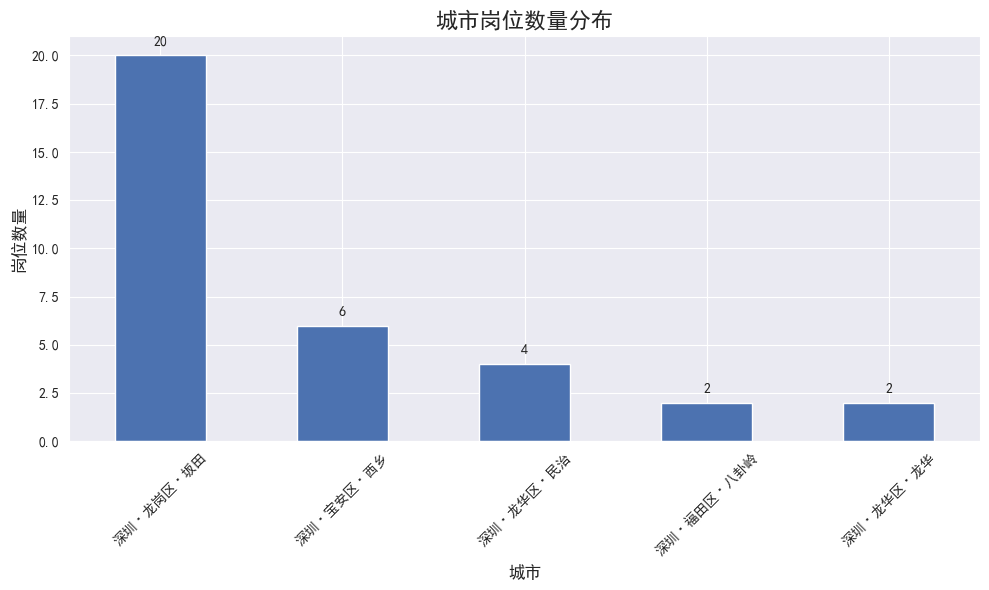

In [5]:
# 统计城市岗位数量（取前5个城市）
city_counts = df['location'].value_counts().head(5)

# 绘制柱状图
plt.figure(figsize=(10, 6))
city_counts.plot(kind='bar', color='#4C72B0')
plt.title('城市岗位数量分布', fontsize=16)
plt.xlabel('城市', fontsize=12)
plt.ylabel('岗位数量', fontsize=12)
plt.xticks(rotation=45)
# 在柱子上显示数值
for i, v in enumerate(city_counts):
    plt.text(i, v + 0.5, str(v), ha='center')
plt.tight_layout()
plt.show()

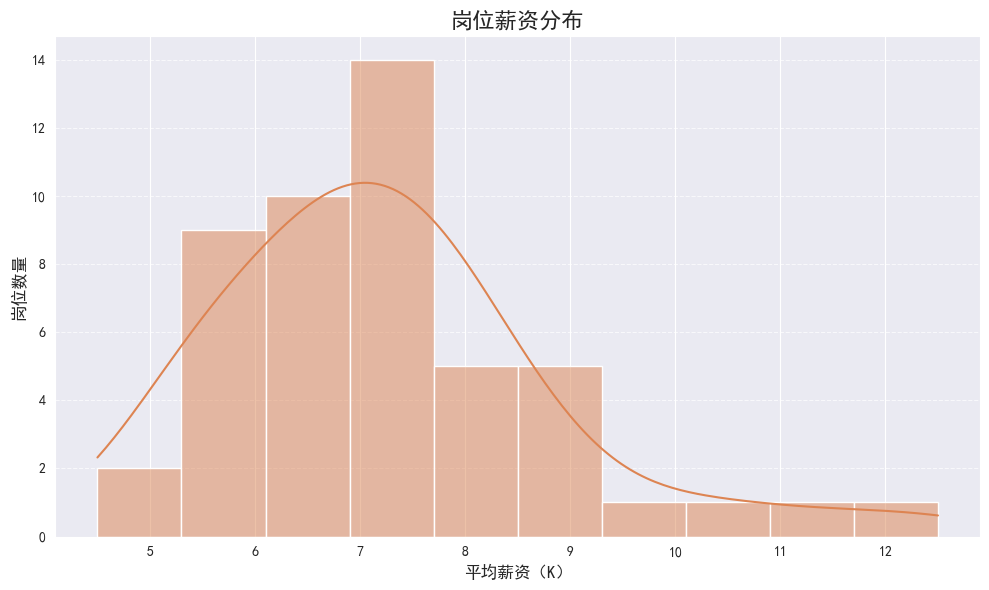

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(df['salary_avg'], bins=10, kde=True, color='#DD8452')
plt.title('岗位薪资分布', fontsize=16)
plt.xlabel('平均薪资（K）', fontsize=12)
plt.ylabel('岗位数量', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

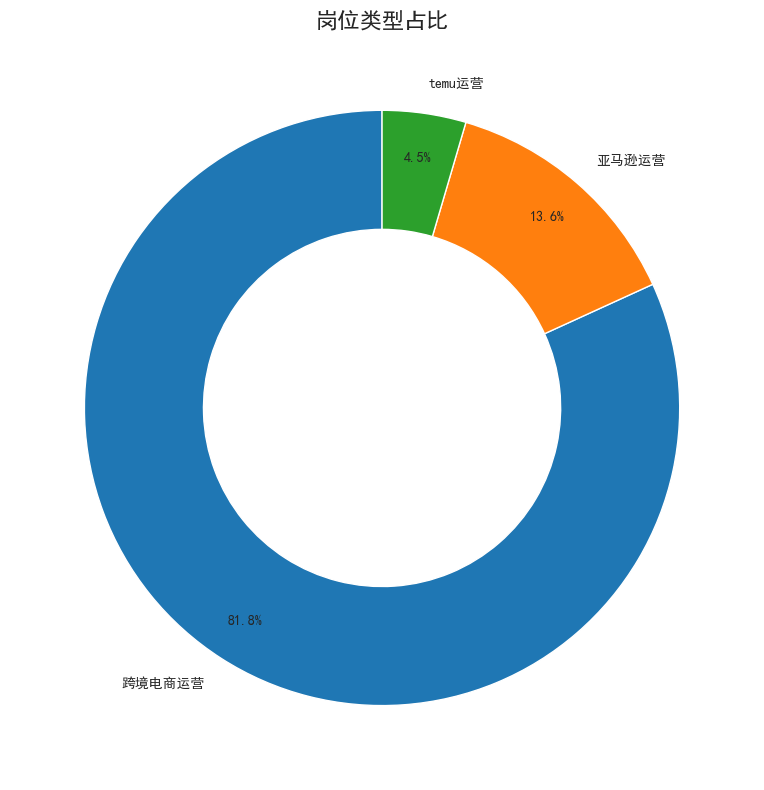

In [7]:
# 提取岗位类型（简化job_name，比如取前几个关键词）
df['job_type'] = df['job_name'].str.extract('(跨境电商运营|亚马逊运营|temu运营|TikTok运营)')
job_counts = df['job_type'].value_counts().dropna()

# 绘制环形图（更美观）
plt.figure(figsize=(8, 8))
plt.pie(job_counts, labels=job_counts.index, autopct='%1.1f%%',
        startangle=90, pctdistance=0.85,
        wedgeprops=dict(width=0.4, edgecolor='w'))
plt.title('岗位类型占比', fontsize=16)
plt.tight_layout()
plt.show()

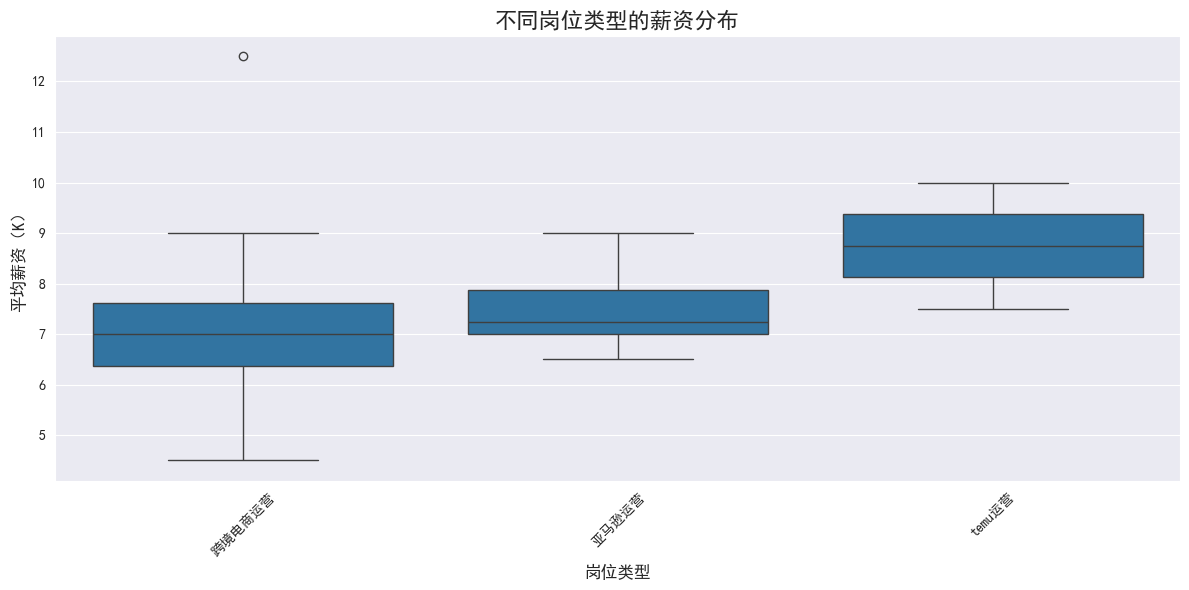

In [8]:
# 薪资 vs 岗位类型的箱线图
plt.figure(figsize=(12, 6))
sns.boxplot(x='job_type', y='salary_avg', data=df.dropna(subset=['job_type']))
plt.title('不同岗位类型的薪资分布', fontsize=16)
plt.xlabel('岗位类型', fontsize=12)
plt.ylabel('平均薪资（K）', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\canway\AppData\Local\Temp\ipykernel_3800\2820929567.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='location', y='salary_avg', data=city_salary_df, palette='Set2')


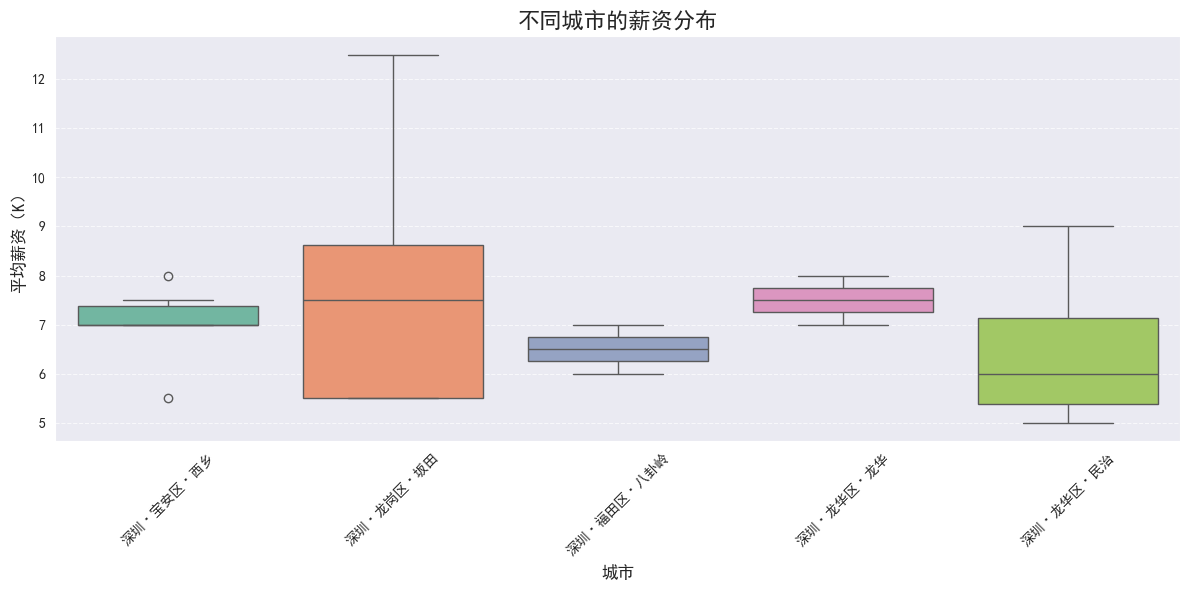

In [9]:
# 不同城市的薪资分布（箱线图）
# 继续使用之前的数据集（df），筛选前5个主要城市
top_cities = df['location'].value_counts().head(5).index
city_salary_df = df[df['location'].isin(top_cities)]

# 绘制箱线图
plt.figure(figsize=(12, 6))
sns.boxplot(x='location', y='salary_avg', data=city_salary_df, palette='Set2')
plt.title('不同城市的薪资分布', fontsize=16)
plt.xlabel('城市', fontsize=12)
plt.ylabel('平均薪资（K）', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

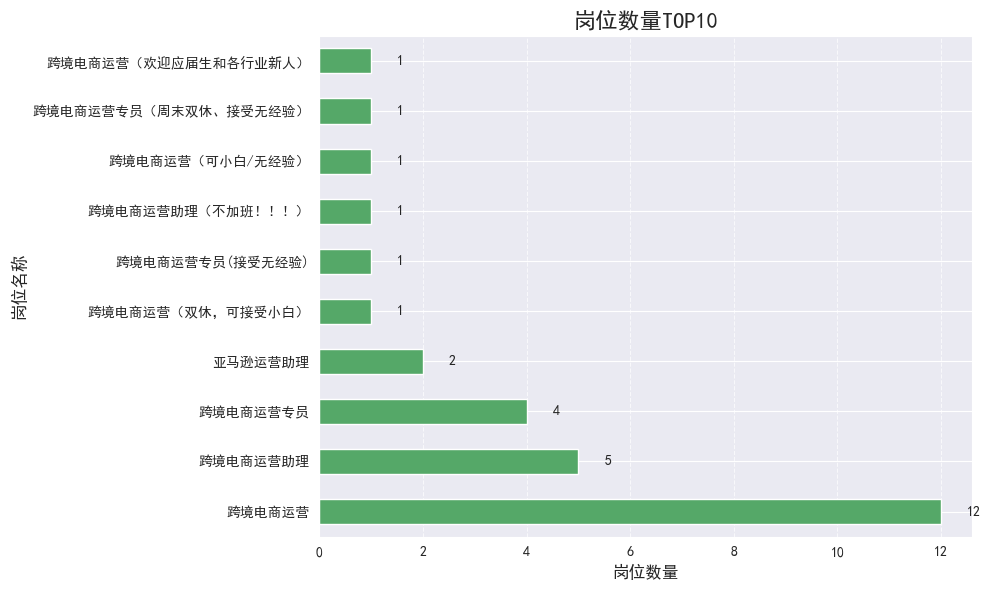

In [11]:
# 岗位数量 TOP10（横向条形图）
# 统计岗位名称数量TOP10
job_name_counts = df['job_name'].value_counts().head(10)

# 绘制横向条形图
plt.figure(figsize=(10, 6))
job_name_counts.plot(kind='barh', color='#55A868')
plt.title('岗位数量TOP10', fontsize=16)
plt.xlabel('岗位数量', fontsize=12)
plt.ylabel('岗位名称', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
# 在条形右侧显示数值
for i, v in enumerate(job_name_counts):
    plt.text(v + 0.5, i, str(v), va='center')
plt.tight_layout()
plt.show()